<h1>PNA Index</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

<h3>PNA index is computed using definition of Wallace and Gutzler (1981)</h3> 
https://doi.org/10.1175/1520-0493(1981)109<0784:TITGHF>2.0.CO;2

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
from io import BytesIO
from PIL import Image
import scipy
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import util, oni, timeutil, stats

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'baseline'

In [4]:
ufs_var = 'phi'
era5_var = 'geopotential'
lev = 500

In [5]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonth = 11

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = 1 #(0, 1, 2, 3)

In [6]:
# For PNA, there are 4 reference locations:
region_1 = {'latmin': 20.0, 'lonmin': 200}
region_2 = {'latmin': 45.0, 'lonmin': 195}
region_3 = {'latmin': 55.0, 'lonmin': 245}
region_4 = {'latmin': 30.0, 'lonmin': 275}

In [7]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>First step is to calculate PNA Index</h3>

<h5>Get data readers</h5>

In [8]:
ufs_data_reader = dr.getDataReader(datasource='UFS',
                                   #filename=f"experiments/phase_1/{ufs_experiment}/atm_monthly.zarr",
                                   experiment=ufs_experiment,
                                   model='atm')

era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr
No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [9]:
ufs_data_reader.describe(ufs_var)


Variable: phi
Dimensions: ('init', 'lead', 'member', 'lat', 'lon', 'lev')
Shape: (60, 4, 11, 192, 384, 39)
Attributes:
  - long_name: Geopotential height
  - units: gpm


In [10]:
era5_data_reader.describe(era5_var)


Variable: geopotential
Dimensions: ('time', 'lat', 'lon', 'lev')
Shape: (92044, 256, 512, 13)
Attributes:
  - long_name: Geopotential
  - short_name: z
  - standard_name: geopotential
  - units: m**2 s**-2


In [11]:
ufs_ds_1 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_1['latmin'], lon=region_1['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    lev=lev,
                                    ens_avg=True).load()  # load

ufs_ds_2 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_2['latmin'], lon=region_2['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    lev=lev,
                                    ens_avg=True).load()  # load

ufs_ds_3 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_3['latmin'], lon=region_3['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    lev=lev,
                                    ens_avg=True).load()  # load

ufs_ds_4 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_4['latmin'], lon=region_4['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    lev=lev,
                                    ens_avg=True).load()  # load

Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average


<h5>Get the corresponding ERA5 data</h5>

In [12]:
# Loading vertical ERA5 data is inherently inefficient.
# Load all lats and lons into memory first, then split into 4 locations.
all_lats = [this_region['latmin'] for this_region in [region_1, region_2, region_3, region_4]]
all_lons = [this_region['lonmin'] for this_region in [region_1, region_2, region_3, region_4]]

In [13]:
# Find nearest lats and lons
all_lats = [era5_data_reader.dataset().sel(lat=this_lat, method='nearest').lat.values.tolist()
            for this_lat in all_lats]

all_lons = [era5_data_reader.dataset().sel(lon=this_lon, method='nearest').lon.values.tolist()
            for this_lon in all_lons]

In [14]:
# Convert to DataArrays (.sel_points() was deprecated, so this is how we do it now.)
all_lats_da = xr.DataArray(all_lats, dims='lat')
all_lons_da = xr.DataArray(all_lons, dims='lon')

In [15]:
# Sel and Load
era5_ds_1234 = era5_data_reader.dataset().sel(lat=all_lats_da,
                                              lon=all_lons_da,
                                              lev=lev,
                                              time=slice(time_range[0], time_range[1]))[[era5_var]].load()  # load

In [16]:
# Split into localities.
era5_ds_1 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[0]], lon=[all_lons[0]]).load()
era5_ds_2 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[1]], lon=[all_lons[1]]).load()
era5_ds_3 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[2]], lon=[all_lons[2]]).load()
era5_ds_4 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[3]], lon=[all_lons[3]]).load()

In [17]:
# Ensure that temporal domains perfectly match.
era5_ds_1 = timeutil.match_time_to_leads(verif_ds=era5_ds_1,
                                         ufs_ds=ufs_ds_1).load()  # load

era5_ds_2 = timeutil.match_time_to_leads(verif_ds=era5_ds_2,
                                         ufs_ds=ufs_ds_2).load()  # load

era5_ds_3 = timeutil.match_time_to_leads(verif_ds=era5_ds_3,
                                         ufs_ds=ufs_ds_3).load()  # load

era5_ds_4 = timeutil.match_time_to_leads(verif_ds=era5_ds_4,
                                         ufs_ds=ufs_ds_4).load()  # load

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [18]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=False)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=False)
ufs_stats_3 = stats.calc_climatology_anomaly(ufs_ds_3, area_mean=False, use_member_climatology=False)
ufs_stats_4 = stats.calc_climatology_anomaly(ufs_ds_4, area_mean=False, use_member_climatology=False)

In [19]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)
era5_stats_3 = stats.calc_climatology_anomaly(era5_ds_3, area_mean=False)
era5_stats_4 = stats.calc_climatology_anomaly(era5_ds_4, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [20]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_var], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_var], stats=ufs_stats_2)
ufs_da_3 = stats.normalize(da=ufs_ds_3[ufs_var], stats=ufs_stats_3)
ufs_da_4 = stats.normalize(da=ufs_ds_4[ufs_var], stats=ufs_stats_4)

In [21]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)
era5_da_3 = stats.normalize(da=era5_stats_3['monthly_mean'], stats=era5_stats_3)
era5_da_4 = stats.normalize(da=era5_stats_4['monthly_mean'], stats=era5_stats_4)

<h2>Calculate PNA Index</h2>

In [22]:
ufs_da_1 = ufs_da_1.squeeze(['lat', 'lon'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['lat', 'lon'])
ufs_da_3 = ufs_da_3.squeeze(['lat', 'lon'])
ufs_da_4 = ufs_da_4.squeeze(['lat', 'lon'])

era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])
era5_da_3 = era5_da_3.squeeze(['lat', 'lon'])
era5_da_4 = era5_da_4.squeeze(['lat', 'lon'])

In [23]:
# Index
ufs_ds_pna = 0.25*(ufs_da_1 - ufs_da_2 + ufs_da_3 - ufs_da_4).to_dataset()
era5_ds_pna = 0.25*(era5_da_1 - era5_da_2 + era5_da_3 - era5_da_4).to_dataset()

<h2>Now that PNA Index is calculated, we can form 2m-temperature composites</h2>

<h5>First, classify which forecast leads (UFS) or times (Verif) are in positive or negative phase</h5>

In [24]:
# This is when ERA5 PNA is positive or negative
era5_positive_exclude_initleads = []
era5_negative_exclude_initleads = []

for this_time in era5_ds_pna.time.values:
    
    # Get calendar month number
    this_month_number = pd.to_datetime(this_time).month
    
    # Calculate lead. two cases for handling calendar months
    if this_month_number >= initmonth:
        this_lead = this_month_number - initmonth
    else:
        this_lead = this_month_number + (12-initmonth)
    
    # Get the corresponding init time
    this_init = timeutil.time_offset(freq_unit='MS',
                                     init=this_time,
                                     lead=this_lead,
                                     step=np.timedelta64(30, 'D'),
                                     direction='backward')
    # This PNA value
    this_pna_value = era5_ds_pna[era5_var].sel(time=this_time).values.item()
    
    # Is this PNA value non-positive or non-negative?
    if this_pna_value >= 0:
        era5_negative_exclude_initleads.append((this_init, this_lead))

    elif this_pna_value <= 0:
        era5_positive_exclude_initleads.append((this_init, this_lead))

In [25]:
# This is when UFS PNA is positive or negative
ufs_positive_exclude_initleads = []
ufs_negative_exclude_initleads = []

for this_init in ufs_ds_pna.init.values:    
    for this_lead in ufs_ds_pna.lead.values:        
        # This PNA value
        this_pna_value = ufs_ds_pna[ufs_var].sel(init=this_init, lead=this_lead).values.item()
        
        # Is this PNA value non-positive or non-negative?
        if this_pna_value >= 0:
            ufs_negative_exclude_initleads.append((this_init, this_lead))
            
        elif this_pna_value <= 0:
            ufs_positive_exclude_initleads.append((this_init, this_lead))

<h3>Compute 2-meter temperature composite</h3>

In [26]:
ufs_var = 'tmp2m'
era5_var = '2m_temperature'

In [27]:
# 1 indicator shall refer to VERIF data
data_reader1 = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [28]:
# 2 indicator shall refer to UFS data
data_reader2 = dr.getDataReader(datasource='UFS',                  
                                experiment = ufs_experiment,
                                # filename=f'experiments/phase_1/{ufs_experiment}/atm_monthly.zarr',                     
                                model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [29]:
ds1 = data_reader1.retrieve(var=era5_var)

In [30]:
ds2 = data_reader2.retrieve(var=ufs_var,
                            time=time_range,
                            initmonths=initmonth,
                            lead=(min(leads), max(leads)),
                            ens_avg=True)

Taking Ensemble Average


In [31]:
# Ensure that temporal domains perfectly match.
ds1 = timeutil.match_time_to_leads(verif_ds=ds1,
                                   ufs_ds=ds2)

In [32]:
# Update datareaders with subsetted data.
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h5>Instantiate Regridder</h5>

In [33]:
regridder = Regrid.Regrid(data_reader1=data_reader1,                                                              
                          data_reader2=data_reader2,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
data_reader1 must be temporally resampled before spatially regridding.
Resample these data by running <RegridObj>.resample(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for resample, run <RegridObj>.resample_vars()

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (ERA5_DataReader): lat 256, lon 512
Output grid shape data_reader2 (UFS_DataReader): lat 192, lon 384
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
data_reader1 can have its time coordinates converted to init+lead.
Lead resolution of the UFS dataset interpreted as monthly intervals.
Align these data by running <RegridObj>.align() (You may need to resample and/or regrid first.)



In [34]:
# Get vars to resample and regrid
vars_to_resample = era5_var
vars_to_regrid = list(globals()[f'data_reader{regridder.highres_grid}'].dataset().keys())
print(f'will resample {vars_to_resample}')
print(f'will regrid {vars_to_regrid}')

will resample 2m_temperature
will regrid ['2m_temperature']


In [35]:
# RESAMPLE.  (Give this a few minutes to complete.)
regridder.resample(var=vars_to_resample)

Resampling data_reader1 data to 'MS' using mean aggregation.
Resampling from 1994-11-01T00 to 2021-12-31T18
Number of cores available: 4
Finished multiprocessing.  Concatenating results.
Resample completed in 1.27 minutes.
Resample results stored in <RegridObj>.resampled


In [36]:
# REGRID.
regridder.regrid(var=vars_to_regrid)

Regridding data_reader1 grid (ERA5_DataReader) onto data_reader2 grid (UFS_DataReader)
Running scalar regrid on 2m_temperature
Completed scalar regrid in 0.03 minutes.
Regrid results stored in <RegridObj>.regridded


In [37]:
# ALIGN.
regridder.align()

Aligning time coordinate to init+lead coordinates.
MODEL_LEADS: [1]
Time dimensions aligned:  matched 28 timesteps
Align results stored in <RegridObj>.aligned


In [38]:
# Datasets have been pre-processed.
# Need some logic here to extract the results.

# For these notebooks, we know that Verif data are aligned:
ds1 = regridder.aligned.dataset()

# UFS data could be in the regridded slot or not, depending on the experiment we're working with.
if regridder.highres_grid == 2:
    ds2 = regridder.regridded.dataset()
else:
    ds2 = data_reader2.dataset()

In [39]:
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h3>Ready for ONI calculations!</h3>

In [42]:
ds1_positive_statistics = oni.calc_composite_layers(data_reader=data_reader1,
                                                    var=era5_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=era5_positive_exclude_initleads)

ds1_negative_statistics = oni.calc_composite_layers(data_reader=data_reader1,
                                                    var=era5_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=era5_negative_exclude_initleads)

ds2_positive_statistics = oni.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=ufs_positive_exclude_initleads)

ds2_negative_statistics = oni.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=ufs_negative_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


<h3>Run t-tests</h3>

In [43]:
# Get position of init and lead axes
dims = list(ds1_positive_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [44]:
# POSITIVE
anomaly_tstatistic_positive, anomaly_pvalue_positive =\
    scipy.stats.ttest_ind(a=ds1_positive_statistics['anomaly'].values,
                          b=ds2_positive_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# NEGATIVE
anomaly_tstatistic_negative, anomaly_pvalue_negative =\
    scipy.stats.ttest_ind(a=ds1_negative_statistics['anomaly'].values,
                          b=ds2_negative_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [45]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_positive': (('lat', 'lon'), anomaly_pvalue_positive),
        'anomaly_pvalue_negative': (('lat', 'lon'), anomaly_pvalue_negative)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h1>Anomaly</h1>

In [46]:
# This is the DataArray for the Composite
ds1_positive_composite = ds1_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_negative_composite = ds1_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_positive_composite = ds2_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_negative_composite = ds2_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
positive_ds2_minus_ds1 = ds2_positive_composite - ds1_positive_composite
negative_ds2_minus_ds1 = ds2_negative_composite - ds1_negative_composite

# Calculate Correlations
positive_corr = xr.corr(ds1_positive_composite, ds2_positive_composite).values.item()
negative_corr = xr.corr(ds1_negative_composite, ds2_negative_composite).values.item()

<h5>Make labels for the plots</h5>

In [47]:
def count_phases(da):
    '''Ad hoc function:  Count the number of init leads with defined data.'''
    n_phases = 0
    # Loop over init-leads
    for this_init in da.init.values:
        for this_lead in da.lead.values:

            # Check if all nan
            if not np.isnan(da.sel(init=this_init, lead=this_lead).values).all():
                n_phases += 1

    return n_phases

In [48]:
n_era5_positive_phases = f"N Positive Phases: {count_phases(ds1_positive_statistics['anomaly'])}"
n_era5_negative_phases = f"N Negative Phases: {count_phases(ds1_negative_statistics['anomaly'])}"

n_ufs_positive_phases = f"N Positive Phases: {count_phases(ds2_positive_statistics['anomaly'])}"
n_ufs_negative_phases = f"N Negative Phases: {count_phases(ds2_negative_statistics['anomaly'])}"

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
positive_corr_label = f'corr: {positive_corr:.2f}'
negative_corr_label = f'corr: {negative_corr:.2f}'

<h3>Generate figures</h3>

In [49]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'mm day-1',
               'cmap': 'BrBG',
               'topleft_label': initlead_label, 
               'region': None,
               'dpi': 200}

plot1 = oni.plot_composite(da = ds1_positive_composite,
                           title=f'{data_reader1.datasource} T2m Anomaly (Positive PNA Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_era5_positive_phases, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = oni.plot_composite(da = ds1_negative_composite,
                           title=f'{data_reader1.datasource} T2m Anomaly (Negative PNA Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_era5_negative_phases, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = oni.plot_composite(da = ds2_positive_composite,
                           title=f'{data_reader2.datasource} T2m Anomaly (Positive PNA Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_ufs_positive_phases, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = oni.plot_composite(da = ds2_negative_composite,
                           title=f'{data_reader2.datasource} T2m Anomaly (Negative PNA Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_ufs_negative_phases, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = oni.plot_composite(da = positive_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_positive'],
                           shading_threshold = 0.05,
                           title=f'{data_reader2.datasource} minus {data_reader1.datasource} T2m Anomaly (Positive PNA Phase)',
                           vmin=-4, vmax=4,
                           bottomright_label=positive_corr_label,
                           **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = oni.plot_composite(da = negative_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_negative'],
                           shading_threshold = 0.05,
                           title=f'{data_reader2.datasource} minus {data_reader1.datasource} T2m Anomaly (Negative PNA Phase)',
                           vmin=-4, vmax=4,
                           bottomright_label=negative_corr_label,
                           **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------


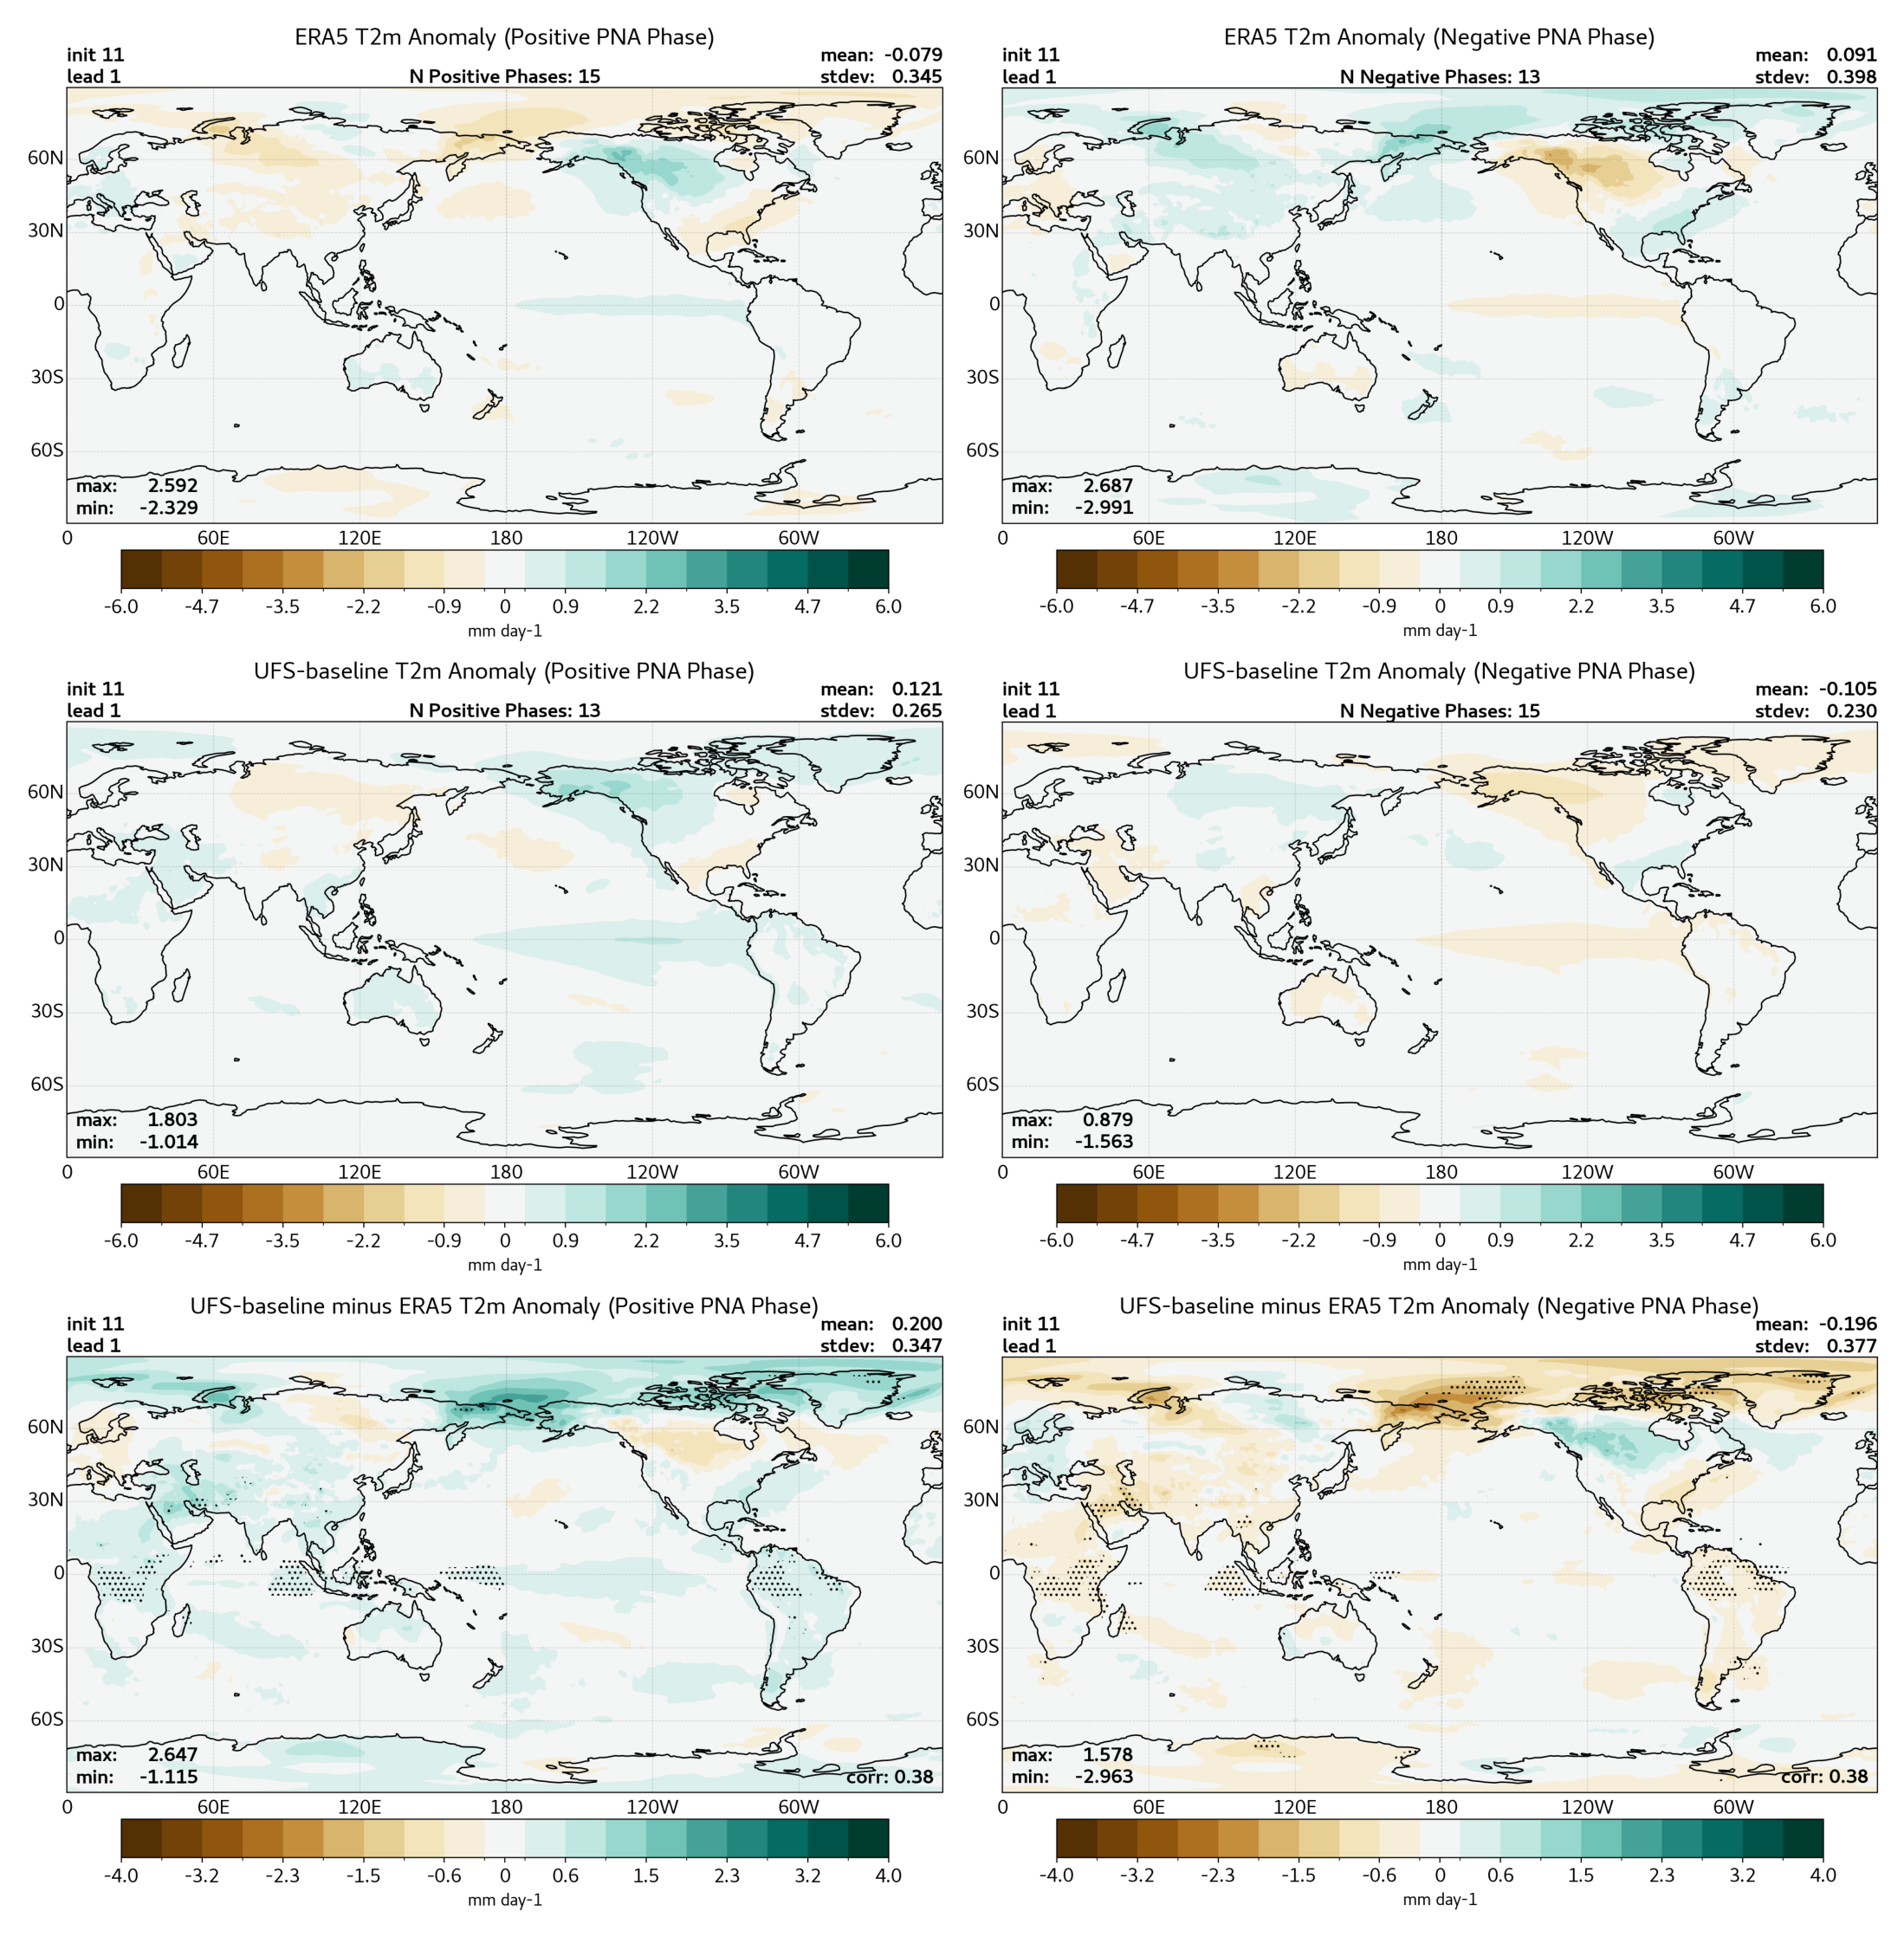

In [50]:
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axs[0, 0].imshow(image1)
axs[0, 0].axis('off')

axs[0, 1].imshow(image2)
axs[0, 1].axis('off')

axs[1, 0].imshow(image3)
axs[1, 0].axis('off')

axs[1, 1].imshow(image4)
axs[1, 1].axis('off')

axs[2, 0].imshow(image5)
axs[2, 0].axis('off')

axs[2, 1].imshow(image6)
axs[2, 1].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=.05)
plt.show()